# PCC计算

正在读取文件: /data4/ceiling/workspace/HCC/evaluation/markers/201615614.4/VirtualMultiplexer_correct_with_noise.csv

归一化基准 (Max Values): Real=57.49, Fake=108.70

分析对象: dapi (Normalized, X=Virtual, Y=Reference)
--------------------------------------------------
斜率 (k) : 0.9811
截距 (b) : 0.0672
相关系数 (r): 0.8045

图片已保存至: /data4/ceiling/workspace/HCC/evaluation/markers/201615614.4/VirtualMultiplexer_regression_analysis_dapi.png
正在读取文件: /data4/ceiling/workspace/HCC/evaluation/markers/201615614.4/VirtualMultiplexer_correct_with_noise.csv

归一化基准 (Max Values): Real=26.76, Fake=37.43

分析对象: foxp3 (Normalized, X=Virtual, Y=Reference)
--------------------------------------------------
斜率 (k) : 0.3260
截距 (b) : 0.1419
相关系数 (r): 0.4798

图片已保存至: /data4/ceiling/workspace/HCC/evaluation/markers/201615614.4/VirtualMultiplexer_regression_analysis_foxp3.png
正在读取文件: /data4/ceiling/workspace/HCC/evaluation/markers/201615614.4/VirtualMultiplexer_correct_with_noise.csv

归一化基准 (Max Values): Real=33.80, Fake=16.08

分析

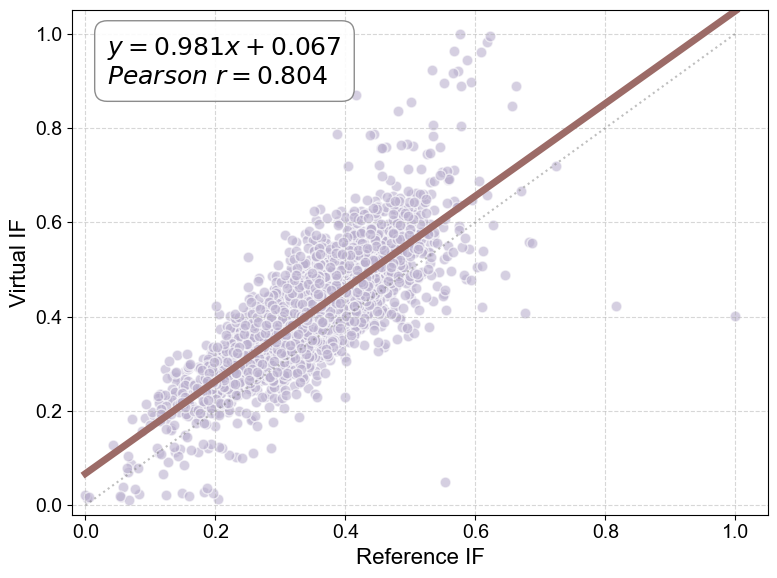

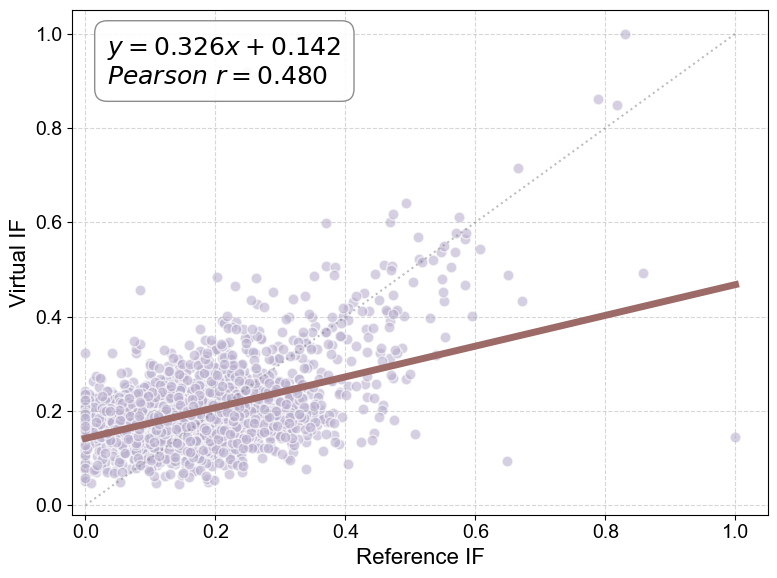

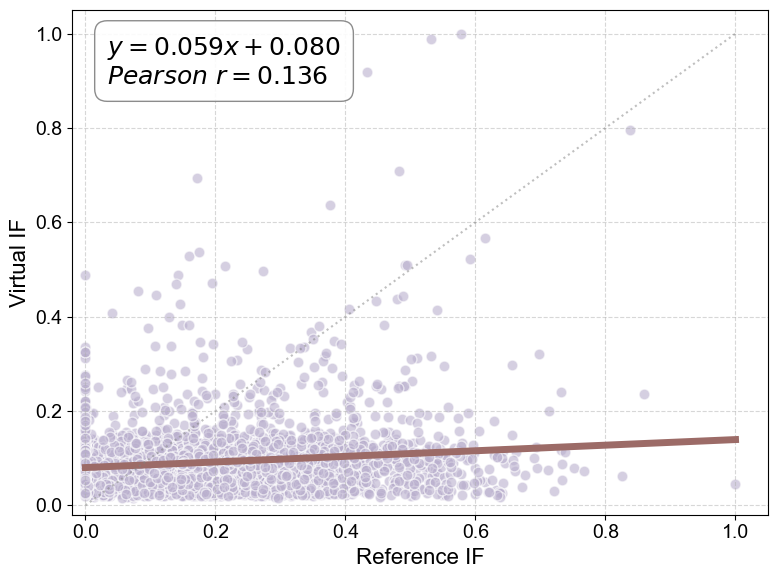

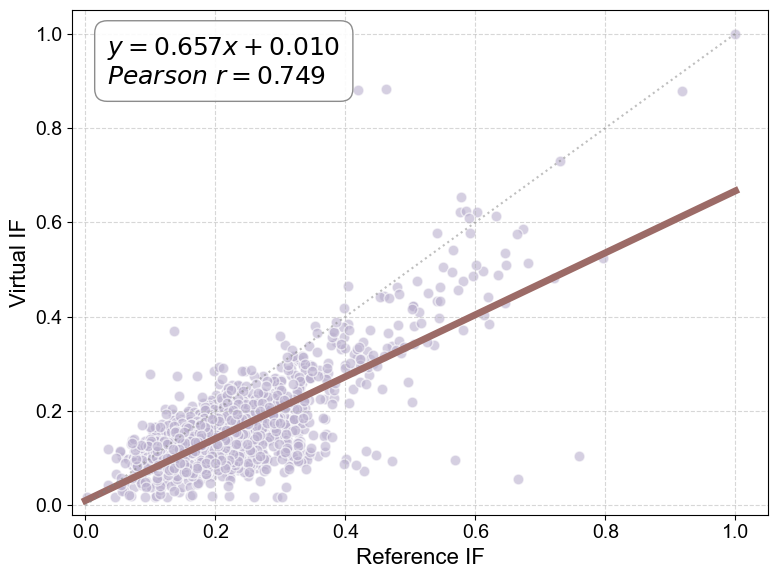

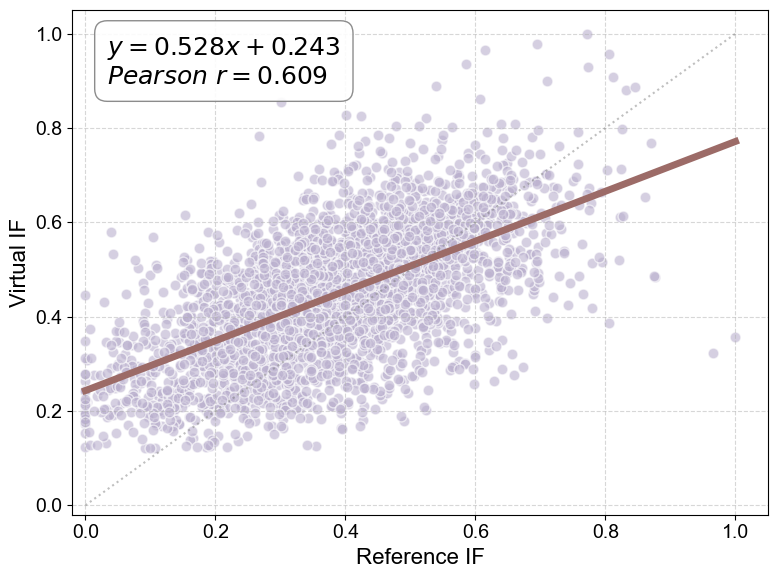

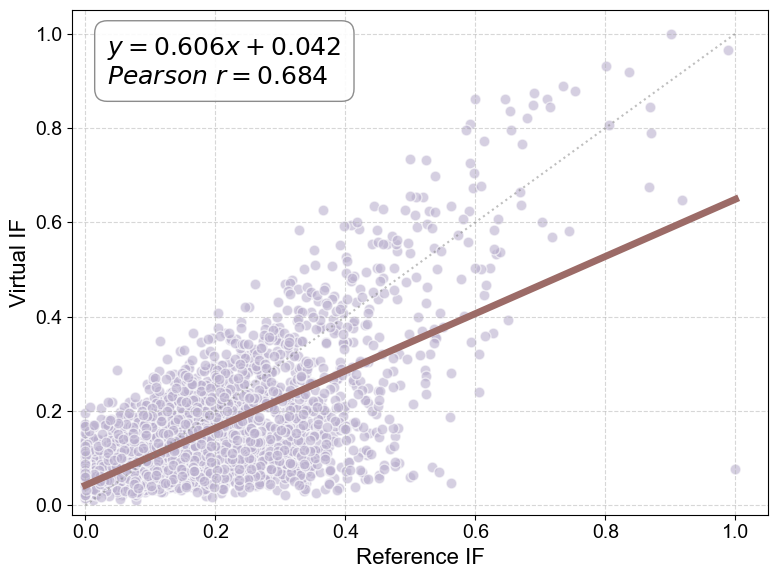

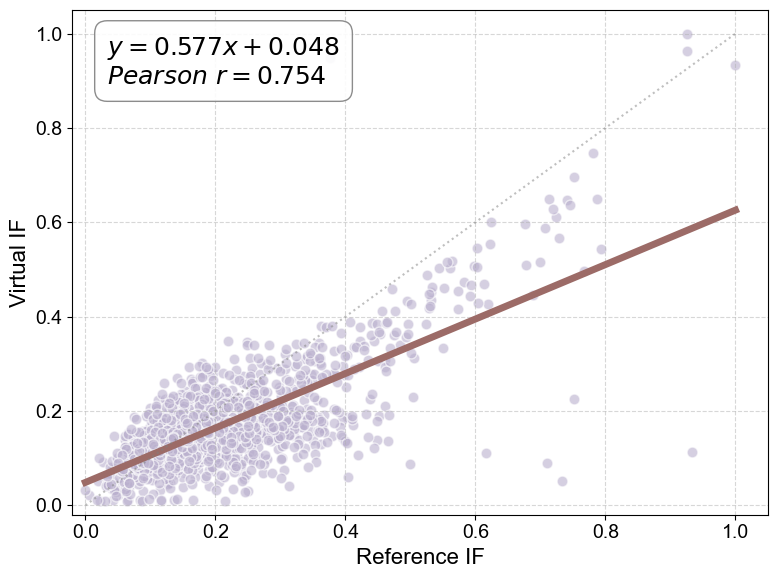

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def plot_normalized_regression(target_marker):
    # ---------------- 配置区域 ----------------
    file_path = '/data4/ceiling/workspace/HCC/evaluation/markers/201615614.4/VirtualMultiplexer_correct_with_noise.csv'
    # 文件名建议改一下，防止覆盖之前的图，或者保持一致看你自己
    save_img_path = f'/data4/ceiling/workspace/HCC/evaluation/markers/201615614.4/VirtualMultiplexer_regression_analysis_{target_marker}.png'
    
    # ---------------- 绘图风格设置 ----------------
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']
    
    plt.rcParams['font.size'] = 14
    plt.rcParams['axes.labelsize'] = 16
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14
    plt.rcParams['legend.fontsize'] = 14
    plt.rcParams['figure.titlesize'] = 16

    # ---------------- 数据处理 ----------------
    print(f"正在读取文件: {file_path}")
    try:
        df = pd.read_csv(file_path, sep=None, engine='python')
    except Exception as e:
        print(f"读取文件失败: {e}")
        return

    real_col = f'real_{target_marker}'
    fake_col = f'fake_{target_marker}'

    if real_col not in df.columns or fake_col not in df.columns:
        print(f"错误: 找不到 {real_col} 或 {fake_col}")
        return

    # 1. 过滤 0 值 (依然根据 Real != 0 来筛选有效数据点)
    data = df[df[real_col] != 0].copy()
    
    # 提取原始数据
    raw_real = data[real_col].values
    raw_fake = data[fake_col].values

    if len(raw_real) < 2:
        print("有效数据点不足。")
        return

    # 2. 归一化处理 (除以各自的最大值)
    max_real = np.max(raw_real)
    max_fake = np.max(raw_fake)
    
    # >>>>> 关键修改：交换 X 和 Y <<<<<
    # X 轴现在是 Virtual (Fake)
    x = raw_fake / max_fake
    # Y 轴现在是 Reference (Real)
    y = raw_real / max_real

    print(f"\n归一化基准 (Max Values): Real={max_real:.2f}, Fake={max_fake:.2f}")

    # ---------------- 统计计算 ----------------
    # 计算回归: Real = k * Virtual + b
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    print("\n" + "="*50)
    print(f"分析对象: {target_marker} (Normalized, X=Virtual, Y=Reference)")
    print("-" * 50)
    print(f"斜率 (k) : {slope:.4f}")
    print(f"截距 (b) : {intercept:.4f}")
    print(f"相关系数 (r): {r_value:.4f}")
    print("="*50)

    # ---------------- 绘图逻辑 ----------------
    plt.figure(figsize=(8, 6)) 
    
    # 绘制散点
    plt.scatter(x, y, alpha=0.6, s=60, color='#BAB0CE', label='Data Points', edgecolors='white')

    # 绘制拟合线
    x_range = np.linspace(0, 1, 100) 
    y_pred = slope * x_range + intercept
    plt.plot(x_range, y_pred, color='#9c6b67', linewidth=5, label='Fit Line')

    # 绘制对角虚线 (Ideal y=x)
    plt.plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.5, label='Ideal (y=x)')

    # >>>>> 关键修改：交换标签 <<<<<
    plt.xlabel(f'Reference IF')    # X轴
    plt.ylabel(f'Virtual IF')  # Y轴

    # 设置坐标轴范围
    plt.xlim(-0.02, 1.05)
    plt.ylim(-0.02, 1.05)

    # 添加公式文本
    sign = '+' if intercept >= 0 else '-'
    formula_text = (f'$y = {slope:.3f}x {sign} {abs(intercept):.3f}$\n'
                    f'$Pearson\ r = {r_value:.3f}$')
    
    plt.text(0.05, 0.95, formula_text, transform=plt.gca().transAxes,
             fontsize=18, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(save_img_path, dpi=300)
    print(f"\n图片已保存至: {save_img_path}")

if __name__ == "__main__":
    markers = ['dapi', 'foxp3', 'cd19', 'cd68', 'cd4', 'cd3', 'cd8']
    for target in markers:
        plot_normalized_regression(target)

In [23]:
import pandas as pd
import numpy as np

def calculate_stats():
    # 读取文件
    file_path = '/data4/ceiling/workspace/HCC/evaluation/markers/201615614.4/HCCExplorer_corrected.csv'
    
    try:
        # 尝试自动推断分隔符
        df = pd.read_csv(file_path, sep=None, engine='python')
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    markers = ['dapi', 'foxp3', 'cd19', 'cd68', 'cd4', 'cd3', 'cd8']
    
    print(f"{'Marker':<10} {'PCC':<10} {'Real Var':<15} {'Fake Var':<15}")
    print("-" * 50)

    for marker in markers:
        real_col = f'real_{marker}'
        fake_col = f'fake_{marker}'
        
        if real_col not in df.columns or fake_col not in df.columns:
            continue
            
        # 筛选 real_marker != 0 的数据
        valid_mask = df[real_col] != 0
        valid_data = df[valid_mask]
        
        if len(valid_data) < 2:
            print(f"{marker:<10} {'N/A':<10} {'N/A':<15} {'N/A':<15}")
            continue

        # 计算 PCC
        pcc = valid_data[real_col].corr(valid_data[fake_col])
        
        # 计算方差
        real_var = valid_data[real_col].var()
        fake_var = valid_data[fake_col].var()
        
        print(f"{marker:<10} {pcc:<10.4f} {real_var:<15.4f} {fake_var:<15.4f}")

if __name__ == "__main__":
    calculate_stats()

Marker     PCC        Real Var        Fake Var       
--------------------------------------------------
dapi       0.8369     191.9308        88.6467        
foxp3      0.7060     4.8635          4.6966         
cd19       0.6740     2.2710          0.6160         
cd68       0.8120     30.4643         30.4933        
cd4        0.7430     21.2807         22.2928        
cd3        0.7270     129.4082        50.9002        
cd8        0.7384     42.5150         95.2802        


In [17]:
import pandas as pd

def round_csv_values():
    file_path = '/data4/ceiling/workspace/HCC/evaluation/markers/201403500.6/VirtualMultiplexer_corrected.csv'
    
    print(f"正在读取文件: {file_path}")
    
    try:
        # 读取文件 (自动检测分隔符)
        df = pd.read_csv(file_path, sep=None, engine='python')
        
        # 将所有数值列保留3位小数
        # round() 函数很智能，它会处理浮点数，而保持整数列(如 x, y) 不变
        df = df.round(3)
        
        # 保存回原文件
        df.to_csv(file_path, index=False)
        
        print("处理完成。")
        print(f"文件已覆盖保存至: {file_path}")
        
        # 打印前几行预览效果
        print("\n数据预览 (前3行):")
        print(df.head(3).to_string())
        
    except Exception as e:
        print(f"发生错误: {e}")

if __name__ == "__main__":
    round_csv_values()

正在读取文件: /data4/ceiling/workspace/HCC/evaluation/markers/201403500.6/VirtualMultiplexer_corrected.csv
处理完成。
文件已覆盖保存至: /data4/ceiling/workspace/HCC/evaluation/markers/201403500.6/VirtualMultiplexer_corrected.csv

数据预览 (前3行):
       x      y  real_dapi  real_foxp3  real_cd19  real_cd68  real_cd4  real_cd3  real_cd8  real_sampleaf  fake_dapi  fake_foxp3  fake_cd19  fake_cd68  fake_cd4  fake_cd3  fake_cd8  fake_sampleaf
0  71885  15347     21.333       6.684      2.534     10.519     4.642    39.212    15.318         14.264     23.658       8.056      3.755     14.462     7.114    17.059    26.330         12.170
1  63693  62451     34.182       4.348      4.355      9.719     7.011     5.249     7.984          8.601     27.039       5.429      3.716     16.931     7.177    11.941    22.091         16.803
2  17613  63475     22.876       6.831      4.927     22.110    12.383    25.932    17.733         14.698     16.565       7.838      3.228     23.299     8.452     9.139    35.387         

In [20]:
import pandas as pd

# 1. 设置文件路径
xlsx_path = '/data4/ceiling/workspace/HCC/evaluation/markers.xlsx'
csv_output_path = xlsx_path.replace('.xlsx', '.csv')

# 2. 读取 Excel 文件
# 如果文件有多个 sheet，默认读取第一个。如果需要指定的，加参数 sheet_name='Sheet1'
try:
    df = pd.read_excel(xlsx_path, engine='openpyxl')
    print(f"成功读取 Excel 文件，包含 {len(df)} 行数据。")
except FileNotFoundError:
    print(f"找不到文件: {xlsx_path}")
    exit()

# 3. 保存为 CSV
# 选项 A: 保存为标准逗号分隔 (Standard CSV)
df.to_csv(csv_output_path, index=False, sep=',') 

# 选项 B: 保存为制表符分隔 (如果你想直接喂给上一个加随机数的脚本，建议用这个)
# df.to_csv(csv_output_path, index=False, sep='\t') 

print(f"转换完成！文件已保存至: {csv_output_path}")

成功读取 Excel 文件，包含 8 行数据。
转换完成！文件已保存至: /data4/ceiling/workspace/HCC/evaluation/markers.csv


图表已保存至: markers_comparison_custom_colors.png


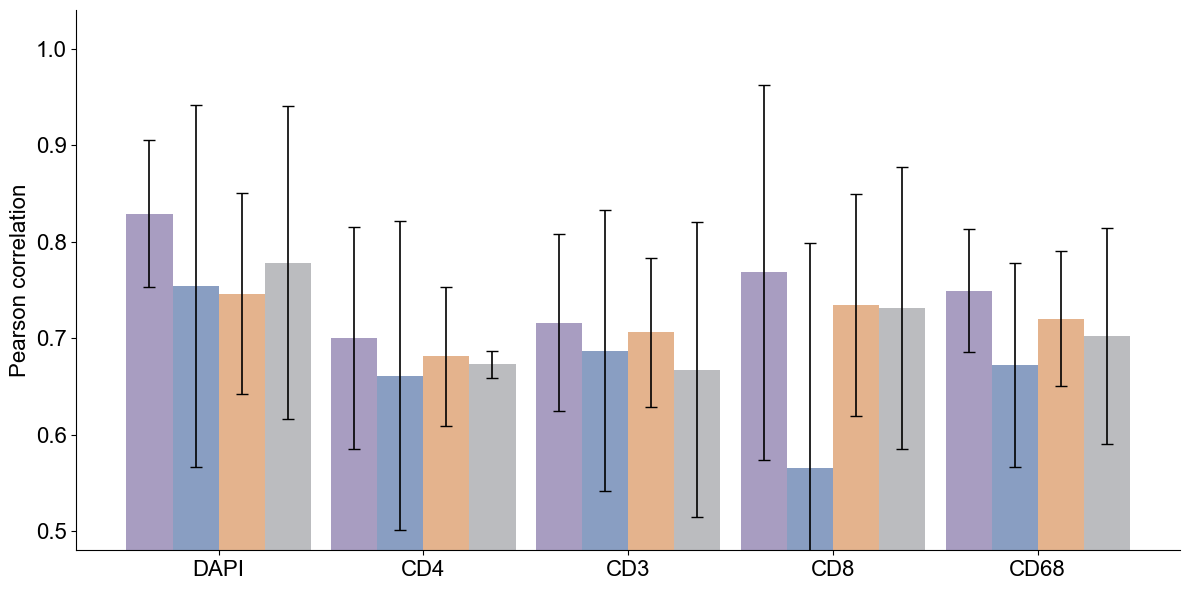

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 设置全局字体为 Arial
plt.rcParams['font.family'] = 'Arial'

# 2. 整理数据
data = {
    'Method': ['HCCExplorer', 'GigaTIME', 'VirtualMultiplexer', 'CUT'],
    
    # DAPI
    'DAPI_mean': [0.829, 0.754, 0.746, 0.778],
    'DAPI_ci':  [0.076, 0.188, 0.104, 0.162],
    
    # CD4
    'CD4_mean':  [0.700, 0.661, 0.681, 0.673], 
    'CD4_std':   [0.115, 0.160, 0.072, 0.014],
    
    # CD3
    'CD3_mean':  [0.716, 0.687, 0.706, 0.667],
    'CD3_ci':   [0.092, 0.146, 0.077, 0.153],
    
    # CD8
    'CD8_mean':  [0.768, 0.565, 0.734, 0.731], 
    'CD8_ci':   [0.194, 0.233, 0.115, 0.146],
    
    # CD68
    'CD68_mean': [0.749, 0.672, 0.720, 0.702],
    'CD68_ci':  [0.064, 0.106, 0.070, 0.112]
}

df = pd.DataFrame(data)

# 定义颜色映射
color_map = {
    'HCCExplorer': '#A89DC1',
    'GigaTIME': '#899EC2',
    'VirtualMultiplexer': '#E4B38D',
    'CUT': '#BBBCBF'
}

# 3. 设置绘图参数
markers = ['DAPI', 'CD4', 'CD3', 'CD8', 'CD68']
methods = df['Method'].tolist()
n_methods = len(methods)

x = np.arange(len(markers))
total_width = 0.9
bar_width = total_width / n_methods

fig, ax = plt.subplots(figsize=(12, 6))

# 4. 循环绘制
for i, method in enumerate(methods):
    row = df[df['Method'] == method].iloc[0]
    
    means = [row[f'{m}_mean'] for m in markers]
    stds = [row[f'{m}_std'] for m in markers]
    
    # 计算偏移量
    # 计算当前方法的 X 轴偏移量
    offset = (i - (n_methods - 1) / 2) * bar_width
    current_x = x + offset    
    # 获取指定颜色
    color = color_map.get(method, '#333333') # 默认深灰
    
    # 绘图
    # alpha=1.0 保证颜色不透明，还原您指定的色值
    rects= ax.bar(x + offset, means, bar_width, yerr=stds, label=method, 
           color=color, capsize=4, alpha=1.0, error_kw={'elinewidth': 1.2})

    if method == 'HCCExplorer':
        # 遍历每个 marker，在柱子上方添加星号
        for j, (mean, std) in enumerate(zip(means, stds)):
            # x坐标: 对应当前 marker 的中心位置 + 偏移量
            text_x = current_x[j]
            # y坐标: 均值 + 标准差 + 一点点间距
            text_y = mean + std + 0.005 
            
            # 添加文本 "**"
            # ax.text(text_x, text_y, '***', ha='center', va='bottom', 
            #         fontsize=16, fontweight='bold', color='black')
            
# 5. 图表美化
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Pearson correlation', fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_xticks(x)
ax.set_xticklabels(markers, fontsize=16)

# 设置Y轴范围
plt.ylim(0.48, 1.04)

# 添加图例
plt.tight_layout()

# 保存
save_path = 'markers_comparison_custom_colors.png'
plt.savefig(save_path, dpi=300)
print(f"图表已保存至: {save_path}")
plt.show()

图表已保存至: markers_comparison_significance.png


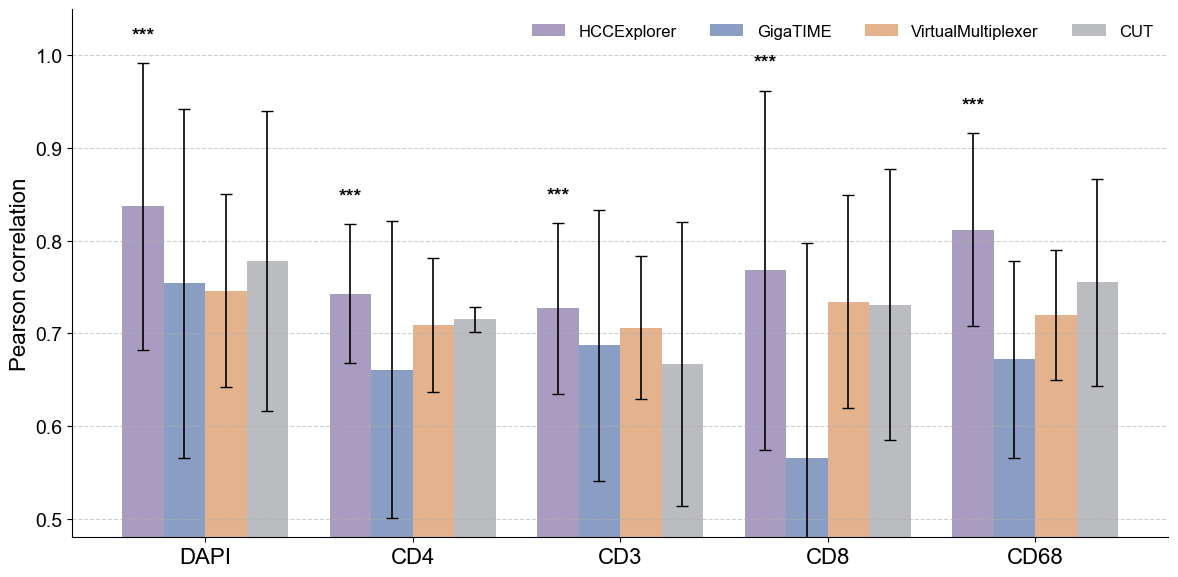